# Interactive Plots with Plotly
v.ekc

Static plots are great for reports, but interactive plots let your reader *explore* the data themselves. This notebook is a showcase of what Plotly Express and ipywidgets can do, followed by open templates so you can try each tool with your own final project dataset.

| Section | Topic |
|---------|-------|
| 1 | Setup |
| 2 | Plotly Express: Hover, Zoom, and Facets |
| 3 | Animations with Plotly |
| 4 | ipywidgets: Sliders and Dropdowns |
| 5 | Combining Widgets with Plotly |
| Appendix | Quick Reference |

---
## 1. Setup

In [21]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display, clear_output

---
## 2. Plotly Express: Hover, Zoom, and Facets

Every Plotly Express chart comes with hover, zoom, and pan for free. The syntax is almost identical to Seaborn: pass a DataFrame, name your columns, and call `fig.show()`.

### 📋 Board Reference

| Function | What it makes |
|----------|---------------|
| `px.scatter(df, x=, y=, color=)` | Scatter plot |
| `px.line(df, x=, y=, color=)` | Line plot |
| `px.histogram(df, x=, color=)` | Histogram |
| `px.box(df, x=, y=, color=)` | Box plot |
| `px.violin(df, x=, y=, color=)` | Violin plot |
| `px.imshow(matrix, text_auto='.2f')` | Heatmap |
| `hover_data=[...]` | Extra columns shown on hover |
| `hover_name='col'` | Bold label at top of tooltip |
| `facet_col='col'` | Small multiples by column |
| `facet_row='col'` | Small multiples by row |

### Demo dataset

We will use the built-in `tips` dataset to show each chart type.

In [22]:
tips = px.data.tips()
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Scatter with hover

Hover over any point to see the full row. `hover_name` adds a bold label at the top of the tooltip.

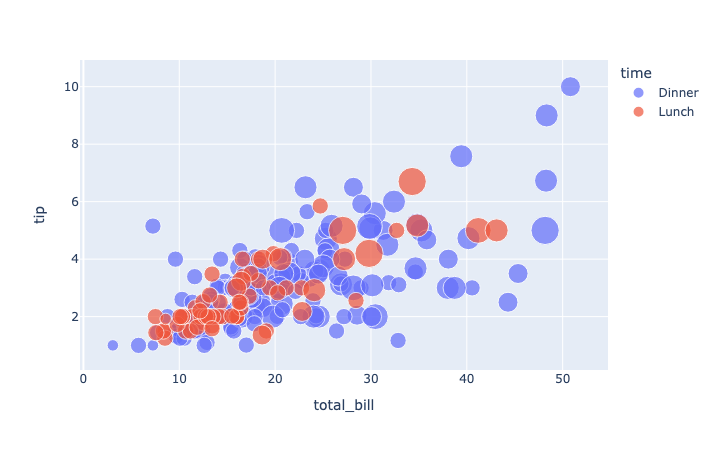

In [3]:
fig = px.scatter(tips, x='total_bill', y='tip',
                 color='time', size='size',
                 hover_name='day',
                 hover_data=['sex', 'smoker'],
                 width=650, height=450)
fig.show()

### Facets

`facet_col` splits into small multiples. Each panel is still interactive.

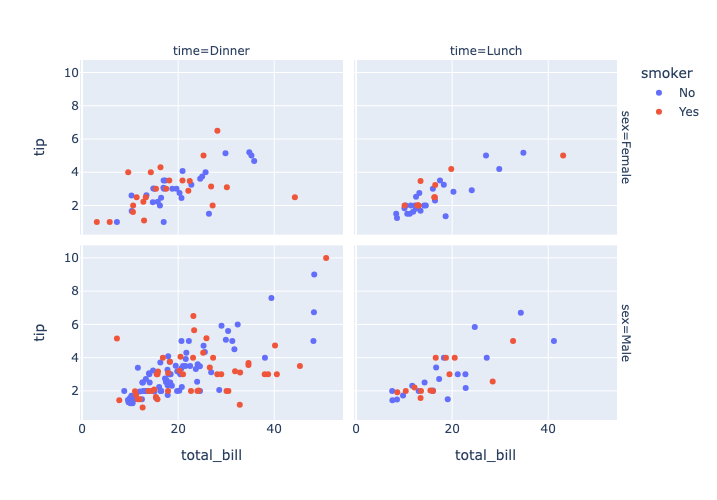

In [4]:
fig = px.scatter(tips, x='total_bill', y='tip',
                 color='smoker',
                 facet_col='time',
                 facet_row='sex',
                 width=700, height=500)
fig.show()

### Histogram

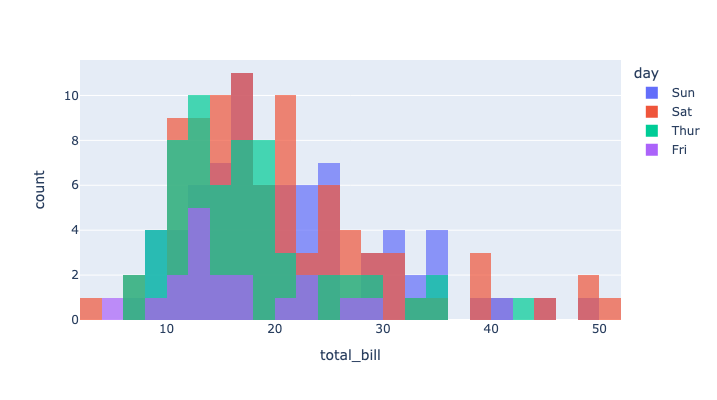

In [8]:
fig = px.histogram(tips, x='total_bill', color='day',
                   barmode='overlay', opacity=0.7,
                   width=650, height=400)
fig.show()

### Box and violin plots

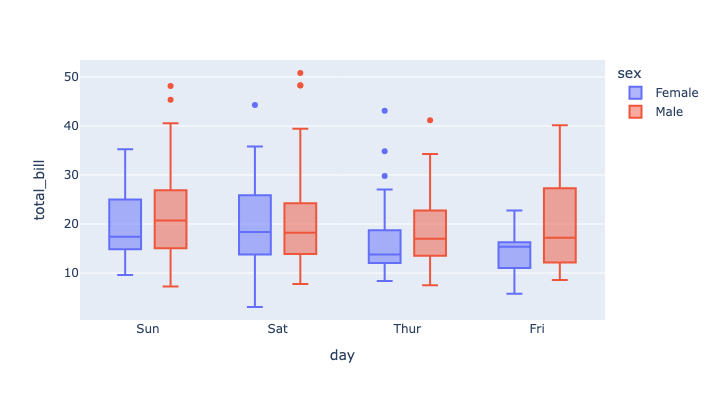

In [9]:
fig = px.box(tips, x='day', y='total_bill',
             color='sex', width=650, height=400)
fig.show()

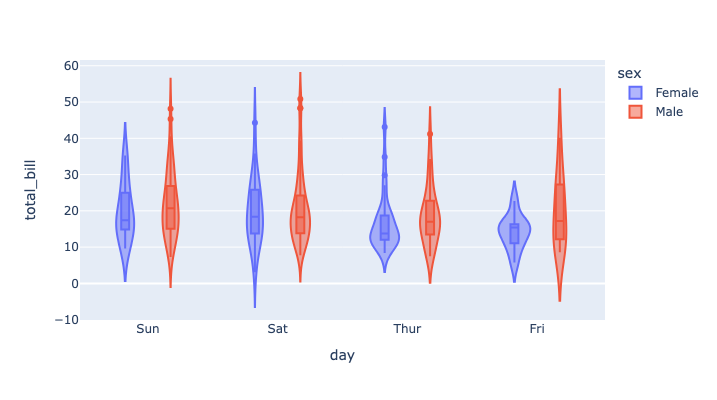

In [10]:
fig = px.violin(tips, x='day', y='total_bill',
                color='sex', box=True,
                width=650, height=400)
fig.show()

### Correlation heatmap

`text_auto` prints the value directly on each cell.

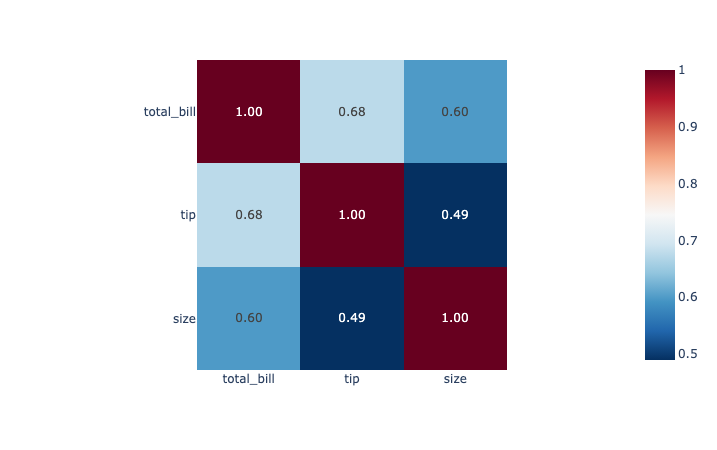

In [11]:
fig = px.imshow(tips.corr(numeric_only=True),
                color_continuous_scale='RdBu_r',
                text_auto='.2f',
                width=500, height=450)
fig.show()

---
### Your Dataset: Basic Interactivity

Load your final project dataset and try the chart types above. Replace the column names with your own.

> **Tip:** `hover_name` works best with a column that uniquely identifies each row, like a name or ID.

In [ ]:
# Load your dataset
your_df = pd.read_csv('YOUR_FILE.csv')
your_df.head()

In [ ]:
# Scatter with hover: swap in your column names
fig = px.scatter(your_df,
                 x='YOUR_X_COLUMN',
                 y='YOUR_Y_COLUMN',
                 color='YOUR_CATEGORY_COLUMN',
                 hover_name='YOUR_LABEL_COLUMN',
                 width=700, height=450)
fig.show()

In [ ]:
# Try a different chart type from the Board Reference above


*What did you discover? (double-click to edit)*

---
## 3. Animations with Plotly

Adding `animation_frame='col'` to any Plotly chart turns it into a time-lapse with a play button. It works on scatter plots, bar charts, line charts, and more.

We will use the Gapminder dataset to show the technique, then you will have a chance to try it with your own data if you have a time or sequence column.

### ETL: getting Gapminder into tidy form

The raw CSV is in wide format. We melt, split, then pivot to get one row per country per year.

In [12]:
df_gap = pd.read_csv('gapminder_all.csv')
long_df = df_gap.melt(id_vars=['continent', 'country'])
long_df[['var', 'year']] = long_df.variable.str.split('_', expand=True)
long_df.drop(columns='variable', inplace=True)
tidy_df = long_df.pivot_table(
    index=['continent', 'country', 'year'],
    columns='var', values='value'
).reset_index()
tidy_df['year'] = tidy_df.year.astype(int)
tidy_df.head()

var,continent,country,year,gdpPercap,lifeExp,pop
0,Africa,Algeria,1952,2449.008185,43.077,9279525.0
1,Africa,Algeria,1957,3013.976023,45.685,10270856.0
2,Africa,Algeria,1962,2550.816880,48.303,11000948.0
3,Africa,Algeria,1967,3246.991771,51.407,12760499.0
4,Africa,Algeria,1972,4182.663766,54.518,14760787.0


### The problem with Seaborn: 12 panels for 12 years

To show change over time in Seaborn you have to facet, which gives you one small panel per year. Hard to follow a single country across the grid.

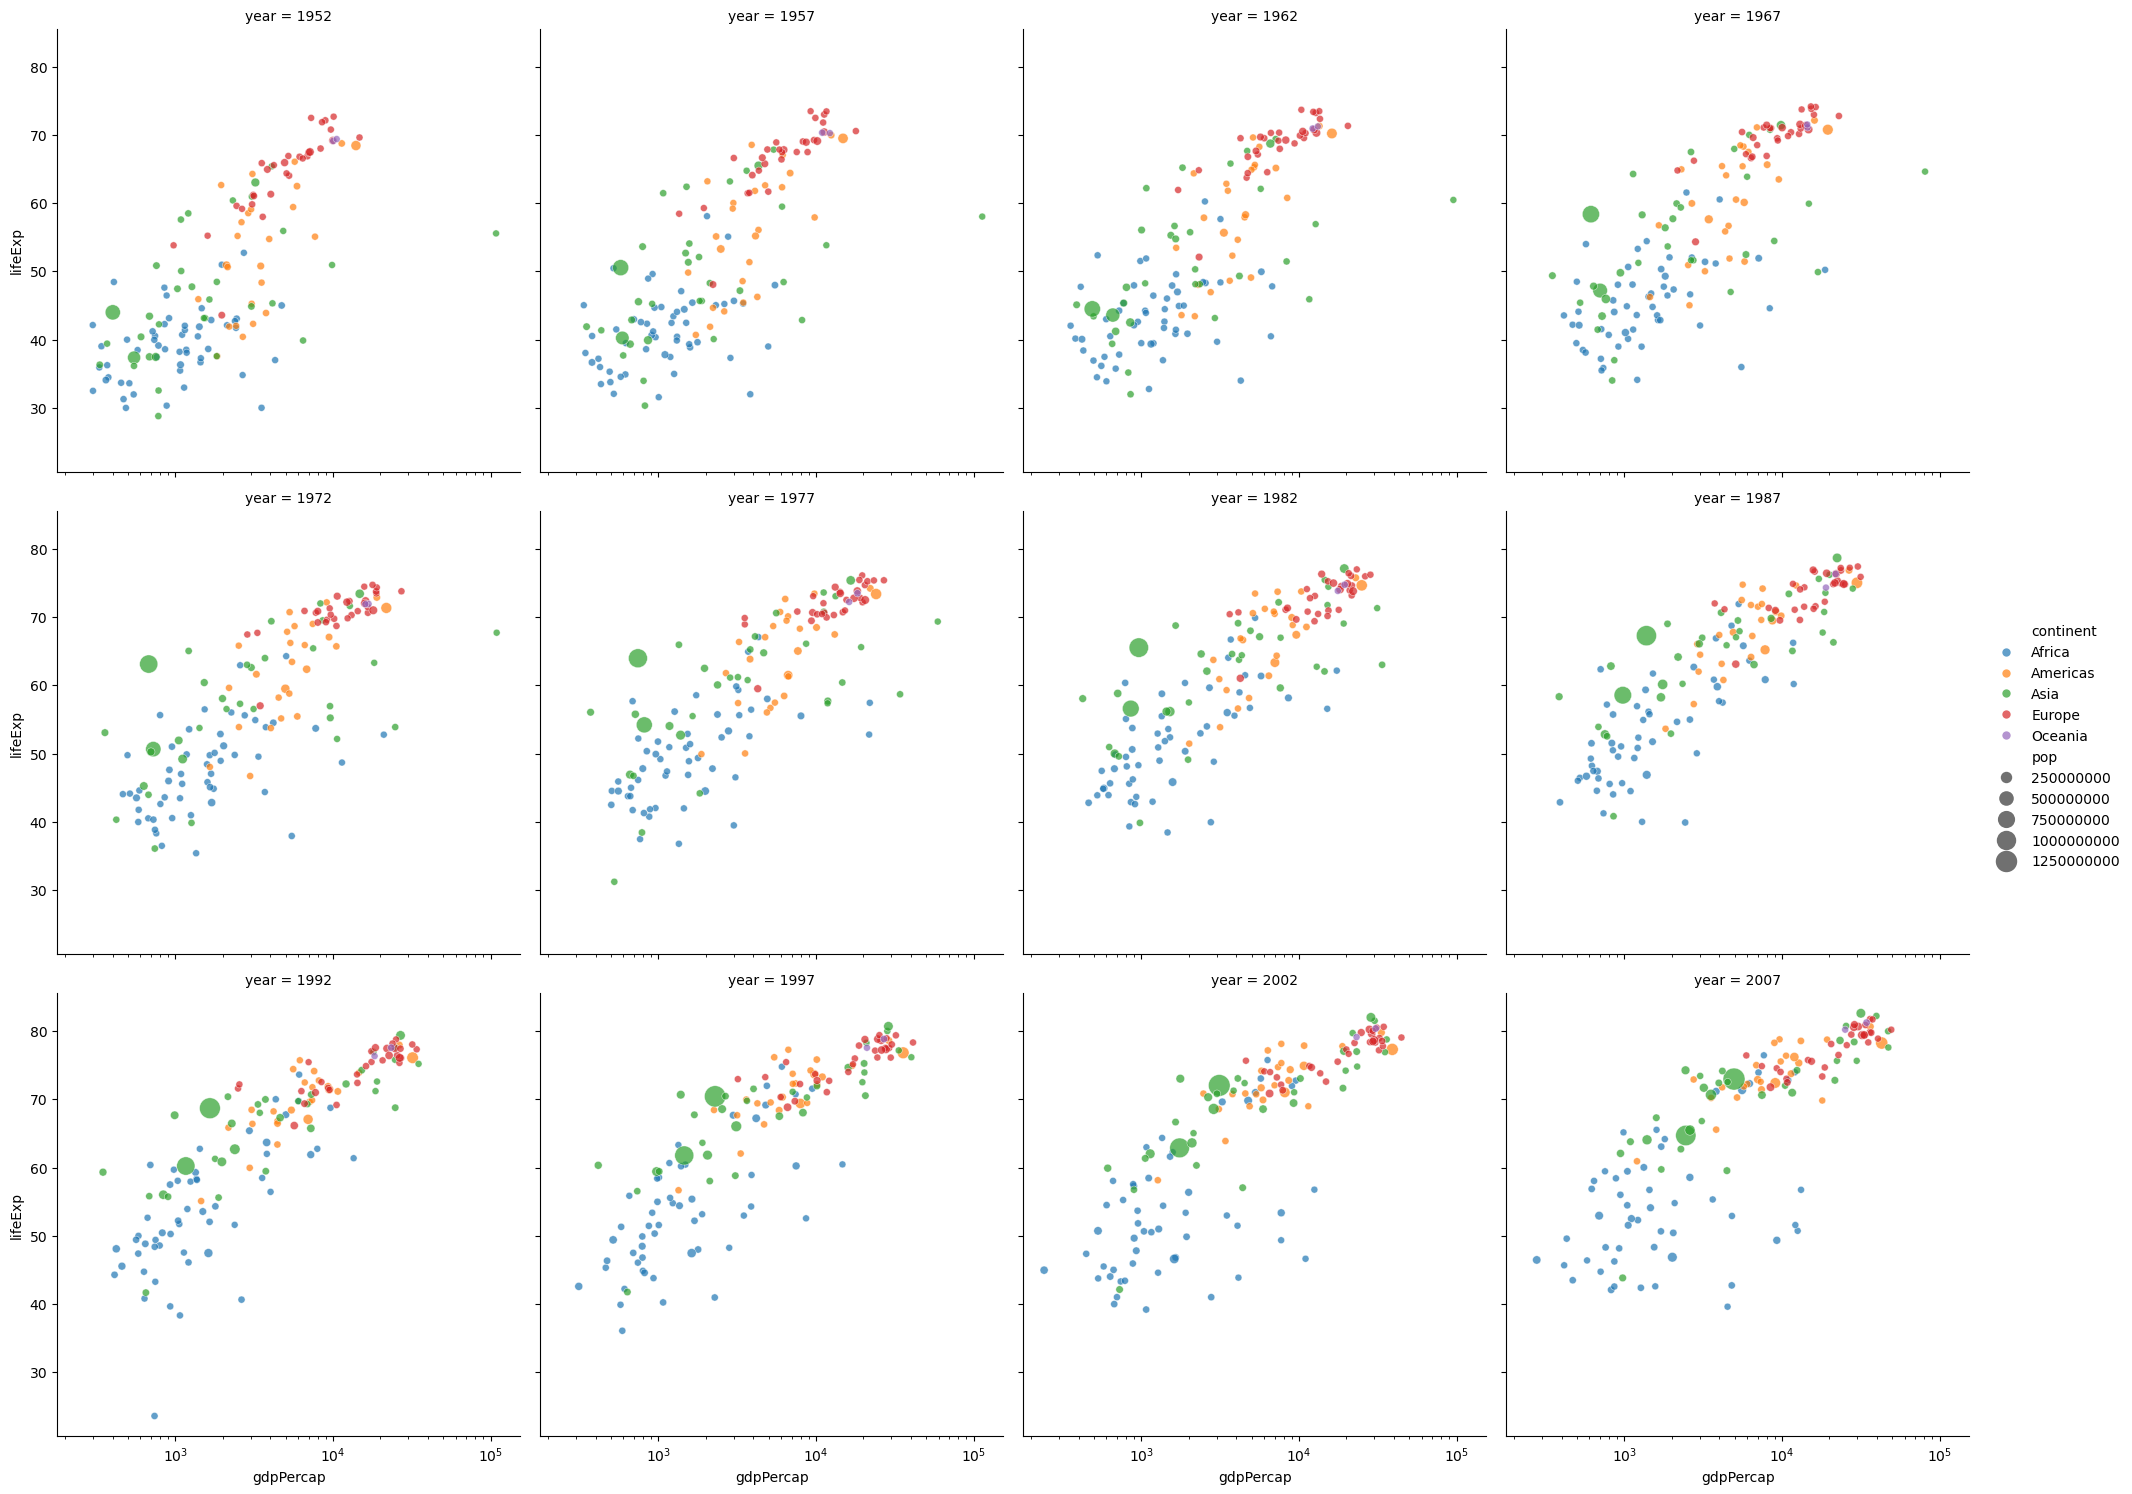

In [13]:
sns.relplot(data=tidy_df, x='gdpPercap', y='lifeExp',
            size='pop', sizes=(25, 250), hue='continent',
            alpha=0.7, col='year', col_wrap=4)
plt.xscale('log')

> **That is 12 tiny panels.** With Plotly, `animation_frame='year'` collapses all of them into one animated chart with a play button.

### Animated scatter

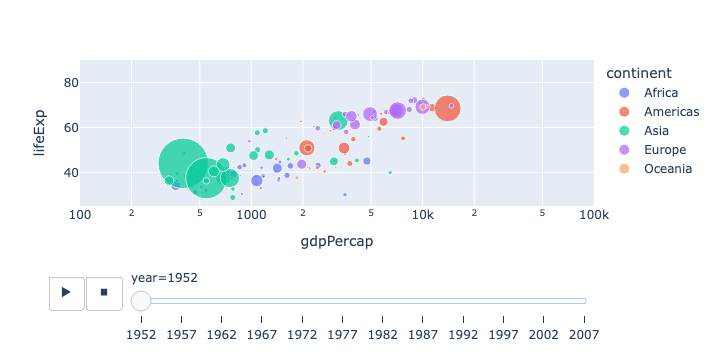

In [14]:
fig = px.scatter(tidy_df, x='gdpPercap', y='lifeExp',
                 size='pop', color='continent',
                 hover_name='country',
                 animation_frame='year',
                 log_x=True, size_max=55,
                 range_x=[100, 100000], range_y=[25, 90])
fig.show()

### Animated bar chart

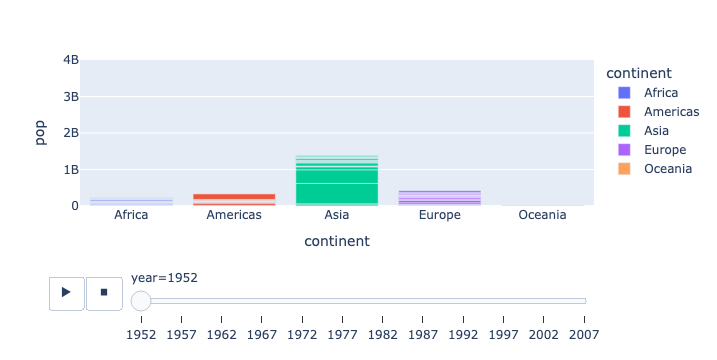

In [15]:
fig = px.bar(tidy_df, x='continent', y='pop',
             color='continent',
             hover_name='country',
             animation_frame='year',
             range_y=[0, 4_000_000_000])
fig.show()

### Animated box plot

Animation is not just for scatter and bar. Here is how distributions shift over time.

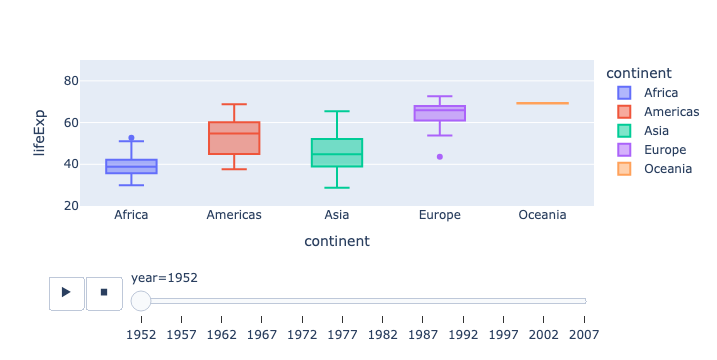

In [30]:
fig = px.box(tidy_df, x='continent', y='lifeExp',
             color='continent',
             animation_frame='year',
             range_y=[20, 90])
fig.show()

---
### Your Dataset: Animation

If your final project dataset has a **time column** (year, month, season, week, etc.) you can use `animation_frame` to animate it.

If your data does not have a time dimension, skip to the next section.

In [ ]:
# Animated scatter with your data
# Replace column names and remove arguments that do not apply
fig = px.scatter(your_df,
                 x='YOUR_X_COLUMN',
                 y='YOUR_Y_COLUMN',
                 color='YOUR_CATEGORY_COLUMN',
                 hover_name='YOUR_LABEL_COLUMN',
                 animation_frame='YOUR_TIME_COLUMN',
                 range_x=[None, None],   # set fixed range so animation is stable
                 range_y=[None, None])
fig.show()

In [ ]:
# Try a different chart type with animation_frame


*What does the animation reveal that a static plot would hide? (double-click to edit)*

---
## 4. ipywidgets: Sliders and Dropdowns

Widgets add real-time controls to your notebook. `interact(func, param=widget)` re-runs `func` every time the widget changes, which means you can let the reader filter, zoom, or switch views without writing a new plot.

### 📋 Board Reference

| Widget | Code | Use case |
|--------|------|----------|
| Integer slider | `widgets.IntSlider(value=, min=, max=)` | Discrete integers |
| Float slider | `widgets.FloatSlider(value=, min=, max=, step=)` | Continuous values |
| Dropdown | `widgets.Dropdown(options=[...], description='Label:')` | Pick from a list |
| Dict dropdown | `widgets.Dropdown(options={'Label': value})` | Human-readable labels |
| Connect to function | `interact(func, param=widget)` | Re-runs on every change |

### Float slider: exploring a function

A slider that changes the frequency of a sine wave. Drag and watch the plot respond.

In [29]:
def sin_func(frequency):
    x = np.linspace(0, 10, 100)
    plt.plot(x, np.sin(frequency * x))
    plt.xlabel('x')
    plt.ylabel('sin(f*x)')
    plt.show()

slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='f:')
interact(sin_func, frequency=slider);

interactive(children=(FloatSlider(value=1.0, description='f:', max=2.0, min=0.1), Output()), _dom_classes=('wi…

### Dropdown: switching between views

`interact()` works well with Matplotlib, but Plotly figures need a different pattern. Use `widgets.Output()` with `observe` instead: create an output area, clear it on each change, and render the new figure inside it.

> **Pattern to remember:** for any Plotly + widget combo, use `Output()` + `observe` rather than `interact()`.

In [27]:
tips = px.data.tips()

plot_out = widgets.Output()

def plot_by_meal(time):
    with plot_out:
        clear_output(wait=True)
        subset = tips[tips['time'] == time]
        fig = px.scatter(subset, x='total_bill', y='tip',
                         color='day', hover_name='day',
                         width=650, height=400)
        fig.show()

dd = widgets.Dropdown(options=['Lunch', 'Dinner'], description='Meal:')
dd.observe(lambda change: plot_by_meal(change['new']), names='value')

display(dd, plot_out)
plot_by_meal('Lunch')   # render initial plot

Dropdown(description='Meal:', options=('Lunch', 'Dinner'), value='Lunch')

Output()

---
### Your Dataset: Widgets

Pick a categorical column in your dataset and use a dropdown to filter the plot. The template below works for any DataFrame.

In [ ]:
# Dropdown filter for your dataset
# Replace column names throughout

categories = your_df['YOUR_CATEGORY_COLUMN'].unique().tolist()

plot_out = widgets.Output()

def plot_category(category):
    with plot_out:
        clear_output(wait=True)
        subset = your_df[your_df['YOUR_CATEGORY_COLUMN'] == category]
        fig = px.scatter(subset,
                         x='YOUR_X_COLUMN',
                         y='YOUR_Y_COLUMN',
                         color='ANOTHER_COLUMN',
                         hover_name='YOUR_LABEL_COLUMN',
                         width=700, height=450)
        fig.show()

dd = widgets.Dropdown(options=categories, description='Category:')
dd.observe(lambda change: plot_category(change['new']), names='value')

display(dd, plot_out)
plot_category(categories[0])   # render initial plot

In [ ]:
# Slider: filter rows above a numeric threshold

min_val = int(your_df['YOUR_NUMERIC_COLUMN'].min())
max_val = int(your_df['YOUR_NUMERIC_COLUMN'].max())

plot_out2 = widgets.Output()

def plot_threshold(threshold):
    with plot_out2:
        clear_output(wait=True)
        subset = your_df[your_df['YOUR_NUMERIC_COLUMN'] >= threshold]
        fig = px.scatter(subset,
                         x='YOUR_X_COLUMN',
                         y='YOUR_Y_COLUMN',
                         color='YOUR_CATEGORY_COLUMN',
                         width=700, height=450)
        fig.show()

sl = widgets.IntSlider(value=min_val, min=min_val, max=max_val, description='Min:')
sl.observe(lambda change: plot_threshold(change['new']), names='value')

display(sl, plot_out2)
plot_threshold(min_val)   # render initial plot

*What does filtering by this variable reveal? (double-click to edit)*

---
## 5. Combining Widgets with Plotly

Wire a dropdown to a Plotly figure and you get a dashboard inside a notebook. Every widget change triggers a full re-render of the chart.

### Adjustable axes

Two dropdowns that let the user pick any x and y column. Every pair re-renders the scatter instantly.

In [23]:
iris = px.data.iris()
num_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

x_dd = widgets.Dropdown(options=num_cols, description='X:')
y_dd = widgets.Dropdown(options=num_cols, value='sepal_width', description='Y:')
plot_out = widgets.Output()

def update_axes(*args):
    with plot_out:
        clear_output(wait=True)
        fig = px.scatter(iris, x=x_dd.value, y=y_dd.value,
                         color='species', hover_name='species',
                         width=650, height=450)
        fig.show()

x_dd.observe(update_axes, names='value')
y_dd.observe(update_axes, names='value')

display(x_dd, y_dd, plot_out)
update_axes()   # render initial plot

Dropdown(description='X:', options=('sepal_length', 'sepal_width', 'petal_length', 'petal_width'), value='sepa…

Dropdown(description='Y:', index=1, options=('sepal_length', 'sepal_width', 'petal_length', 'petal_width'), va…

Output()

### Animation + widget

You can layer a widget on top of an animation. Here a dropdown toggles the x-axis scale while the animation still plays.

In [24]:
scale_dd = widgets.Dropdown(
    options={'Log scale': True, 'Linear scale': False},
    description='X scale:')
plot_out = widgets.Output()

def gapminder_view(log_scale):
    with plot_out:
        clear_output(wait=True)
        x_range = [100, 100000] if log_scale else [0, 45000]
        fig = px.scatter(tidy_df, x='gdpPercap', y='lifeExp',
                         size='pop', color='continent',
                         hover_name='country',
                         animation_frame='year',
                         log_x=log_scale,
                         size_max=55,
                         range_x=x_range, range_y=[25, 90])
        fig.show()

scale_dd.observe(lambda change: gapminder_view(change['new']), names='value')

display(scale_dd, plot_out)
gapminder_view(True)   # render initial plot

Dropdown(description='X scale:', options={'Log scale': True, 'Linear scale': False}, value=True)

Output()

### Continent filter + animation

Filter to one continent and animate across years.

In [25]:
continents = tidy_df['continent'].unique().tolist()

continent_dd = widgets.Dropdown(options=continents, description='Continent:')
plot_out = widgets.Output()

def continent_animation(continent):
    with plot_out:
        clear_output(wait=True)
        subset = tidy_df[tidy_df['continent'] == continent]
        fig = px.scatter(subset, x='gdpPercap', y='lifeExp',
                         size='pop', hover_name='country',
                         animation_frame='year',
                         log_x=True, size_max=55,
                         range_x=[100, 100000], range_y=[25, 90])
        fig.show()

continent_dd.observe(lambda change: continent_animation(change['new']), names='value')

display(continent_dd, plot_out)
continent_animation(continents[0])   # render initial plot

Dropdown(description='Continent:', options=('Africa', 'Americas', 'Asia', 'Europe', 'Oceania'), value='Africa'…

Output()

---
### Your Dataset: Widgets + Plotly

Build something you could actually show in your final project. Start with one of the templates below and adapt it to your data.

In [26]:
# Adjustable axes for your dataset
your_num_cols = your_df.select_dtypes('number').columns.tolist()
your_cat_cols = your_df.select_dtypes('object').columns.tolist()

x_dd  = widgets.Dropdown(options=your_num_cols, description='X:')
y_dd  = widgets.Dropdown(options=your_num_cols, description='Y:')
c_dd  = widgets.Dropdown(options=your_cat_cols, description='Color:')
plot_out = widgets.Output()

def your_axis_plot(*args):
    with plot_out:
        clear_output(wait=True)
        fig = px.scatter(your_df,
                         x=x_dd.value, y=y_dd.value, color=c_dd.value,
                         width=700, height=450)
        fig.show()

for dd in [x_dd, y_dd, c_dd]:
    dd.observe(your_axis_plot, names='value')

display(x_dd, y_dd, c_dd, plot_out)
your_axis_plot()   # render initial plot

NameError: name 'your_df' is not defined

In [ ]:
# Filter dropdown + animation_frame

category_opts = your_df['YOUR_CATEGORY_COLUMN'].unique().tolist()
filter_dd = widgets.Dropdown(options=category_opts, description='Filter:')
plot_out2 = widgets.Output()

def your_animated_view(category):
    with plot_out2:
        clear_output(wait=True)
        subset = your_df[your_df['YOUR_CATEGORY_COLUMN'] == category]
        fig = px.scatter(subset,
                         x='YOUR_X_COLUMN',
                         y='YOUR_Y_COLUMN',
                         color='ANOTHER_COLUMN',
                         hover_name='YOUR_LABEL_COLUMN',
                         animation_frame='YOUR_TIME_COLUMN')
        fig.show()

filter_dd.observe(lambda change: your_animated_view(change['new']), names='value')

display(filter_dd, plot_out2)
your_animated_view(category_opts[0])   # render initial plot

*Describe what a reader can explore with your interactive plot: (double-click to edit)*

---
## Appendix: Quick Reference

### Plotly Express: minimal template
```python
import plotly.express as px

fig = px.scatter(df, x='col1', y='col2', color='group', hover_name='label')
fig.show()
```

### Plotly Express: full options
```python
fig = px.scatter(df, x='col1', y='col2',
                 color='group',
                 size='col3',
                 hover_name='label',
                 hover_data=['extra1', 'extra2'],
                 facet_col='group',
                 facet_row='group2',
                 log_x=True,
                 animation_frame='time_col',
                 range_x=[0, 100],
                 range_y=[0, 100],
                 size_max=40,
                 width=700, height=500)
fig.show()

px.line(df, x=, y=, color=, animation_frame=)    # line chart
px.bar(df, x=, y=, color=, animation_frame=)     # bar chart
px.histogram(df, x=, color=, barmode='overlay')  # histogram
px.box(df, x=, y=, color=)                       # box plot
px.violin(df, x=, y=, color=, box=True)          # violin plot
px.imshow(df.corr(), text_auto='.2f')            # heatmap
```

### ipywidgets: template
```python
from ipywidgets import interact
import ipywidgets as widgets

# Widgets
slider  = widgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.5, description='Val:')
dd_list = widgets.Dropdown(options=['a', 'b', 'c'], description='Choice:')
dd_dict = widgets.Dropdown(options={'Option A': 'a', 'Option B': 'b'}, description='Choice:')

# Wire to a function
def my_plot(param):
    fig = px.scatter(df, x='col1', y='col2')
    fig.show()

interact(my_plot, param=slider);
```